<font color="#CA0032"><h1 align="left">**Redes recurrentes profundas**</h1></font>

<font color="#6E6E6E"><h1 align="left">**Predicción de series temporales**</h1></font>

<h2 align="left">Manuel Sánchez-Montañés</h2>

<font color="#6E6E6E"><h2 align="left">manuel.smontanes@gmail.com</h2></font>

**Notebook: Manuel Sánchez-Montañés**

**Datos: Carlos Rosado**

### **Usaremos un esquema many to one:**

<img src="https://drive.google.com/uc?export=download&id=1iokh576AiK2iFhftPogSBsNXixAi-LBg" align="center" style="float" width="500">

In [1]:
COLAB = True

## <font color="#CA3532"> **1. Importar librerías**

In [2]:
import numpy as np
import pandas as pd

from keras.models import Sequential, load_model
from keras.layers import Dense, LSTM, GRU
from keras.callbacks import ModelCheckpoint

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score as R2_score

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import os

# fijo la semilla aleatoria por reproducibilidad
np.random.seed(7)

In [3]:
def grafica_entrenamiento(tr_mse, val_mse):
    ax=plt.figure(figsize=(10,4)).gca()
    plt.plot(1+np.arange(len(tr_mse)), tr_mse)
    plt.plot(1+np.arange(len(val_mse)), val_mse)
    plt.title('mse del modelo', fontsize=18)
    plt.xlabel('epoca', fontsize=18)
    plt.ylabel('mse', fontsize=18)
    plt.legend(['entrenamiento', 'validación'], loc='upper left')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()

In [4]:
def download_file_from_google_drive(file_id, dest_file, unzip=False):
  aux = "'https://drive.usercontent.google.com/download?id={}&export=download&confirm=t&uuid=9699f0e2-e760-49fc-b12e-49f140095280'".format(file_id)
  !wget $aux -O $dest_file
  if unzip:
    !unzip -qq -o $dest_file
    !rm $dest_file

## <font color="#CA3532"> **2. Carga de datos**

In [5]:
!ls

sample_data


In [6]:
if COLAB:
    download_file_from_google_drive(file_id='12QZpA_L1JncFIVEryee0aeL66Ep3xpOy', dest_file='./datos_pasajeros.csv')

data = pd.read_csv('datos_pasajeros.csv', parse_dates=["fecha"])
data.head(20)

--2026-05-28 10:12:03--  https://drive.usercontent.google.com/download?id=12QZpA_L1JncFIVEryee0aeL66Ep3xpOy&export=download&confirm=t&uuid=9699f0e2-e760-49fc-b12e-49f140095280
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.253.117.132, 2607:f8b0:400e:c0a::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.253.117.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19189 (19K) [application/octet-stream]
Saving to: ‘./datos_pasajeros.csv’

./datos_pasajeros.c 100%[===================>]  18.74K  --.-KB/s    in 0s      

2026-05-28 10:12:04 (77.0 MB/s) - ‘./datos_pasajeros.csv’ saved [19189/19189]



,fecha,mes,festivo,npasajeros,semana_mes,day_of_week
0,2015-01-01,1,1,1125,0,3
1,2015-01-02,1,0,3592,0,4
2,2015-01-03,1,0,3001,0,5
3,2015-01-04,1,0,2260,0,6
4,2015-01-05,1,0,2767,0,0
5,2015-01-06,1,1,1342,0,1
6,2015-01-07,1,0,3867,0,2
7,2015-01-08,1,0,3904,1,3
8,2015-01-09,1,0,3678,1,4
9,2015-01-10,1,0,2631,1,5


In [7]:
data.tail()

,fecha,mes,festivo,npasajeros,semana_mes,day_of_week
785,2017-02-24,2,0,4199,2,4
786,2017-02-25,2,0,2534,2,5
787,2017-02-26,2,0,1816,2,6
788,2017-02-27,2,0,3990,2,0
789,2017-02-28,2,0,3876,2,1


In [8]:
data.shape

(790, 6)

In [9]:
data.head(10)

,fecha,mes,festivo,npasajeros,semana_mes,day_of_week
0,2015-01-01,1,1,1125,0,3
1,2015-01-02,1,0,3592,0,4
2,2015-01-03,1,0,3001,0,5
3,2015-01-04,1,0,2260,0,6
4,2015-01-05,1,0,2767,0,0
5,2015-01-06,1,1,1342,0,1
6,2015-01-07,1,0,3867,0,2
7,2015-01-08,1,0,3904,1,3
8,2015-01-09,1,0,3678,1,4
9,2015-01-10,1,0,2631,1,5


In [10]:
# tam ventana = 3

# primera ventana: predecir y=1125 en función de X = [[nan], [nan], [nan]]
# shape de esa primera ventana: (3,1)

# segunda ventana: predecir y=3592 en función de X = [[nan], [nan], [1125]]
# shape de esa primera ventana: (3,1)

# tercera ventana: predecir y=3001 en función de X = [[nan], [1125], [3592]]
# shape de esa primera ventana: (3,1)

# cuarta ventana: predecir y=2260 en función de X = [[1125], [3592], [3001]]
# shape de esa primera ventana: (3,1)

# quinta ventana: predecir y=2767 en función de X = [[3592], [3001], [2260]]
# shape de esa primera ventana: (3,1)

# Si solo tengo esas cinco ventanas:

# y.shape = (5,)
# X.shape = (5,3,1)

In [11]:
!ls -la

total 36
drwxr-xr-x 1 root root  4096 May 28 10:12 .
drwxr-xr-x 1 root root  4096 May 28 09:56 ..
drwxr-xr-x 4 root root  4096 May 26 13:25 .config
-rw-r--r-- 1 root root 19189 May 26  2023 datos_pasajeros.csv
drwxr-xr-x 1 root root  4096 May 26 13:25 sample_data


In [12]:
data.shape

(790, 6)

In [13]:
data["fecha"].diff().value_counts()

,count
fecha,
1 days,789


In [14]:
data.shape

(790, 6)

In [15]:
data["fecha"].nunique()

790

## <font color="#CA3532"> **3. Preprocesado inicial y visualización de datos**

In [16]:
data.dtypes

,0
fecha,datetime64[ns]
mes,int64
festivo,int64
npasajeros,int64
semana_mes,int64
day_of_week,int64


In [17]:
fechas = data["fecha"].values
target = data["npasajeros"].values

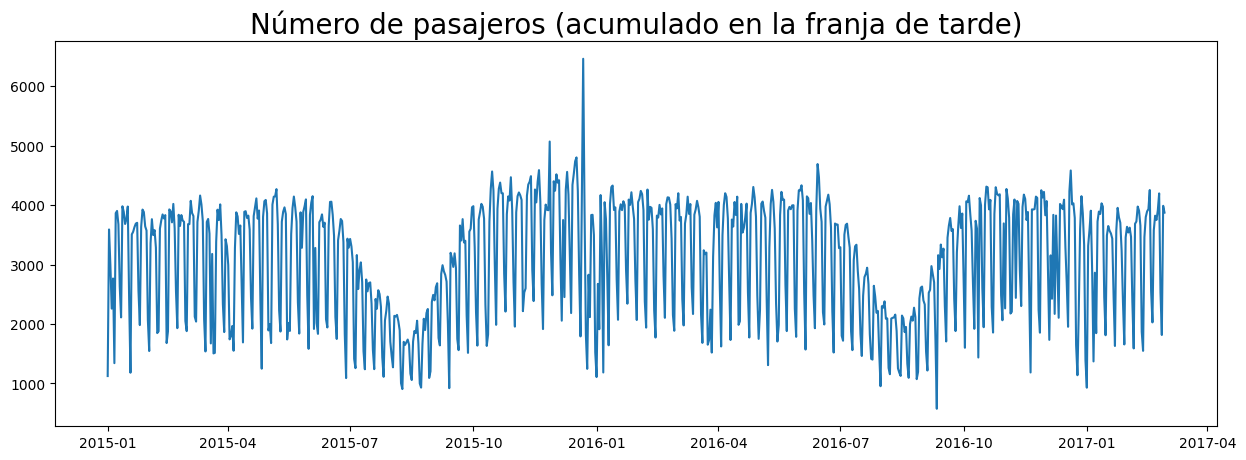

In [18]:
plt.figure(figsize=(15,5))
plt.plot(fechas, target)
plt.title("Número de pasajeros (acumulado en la franja de tarde)", fontsize=20);

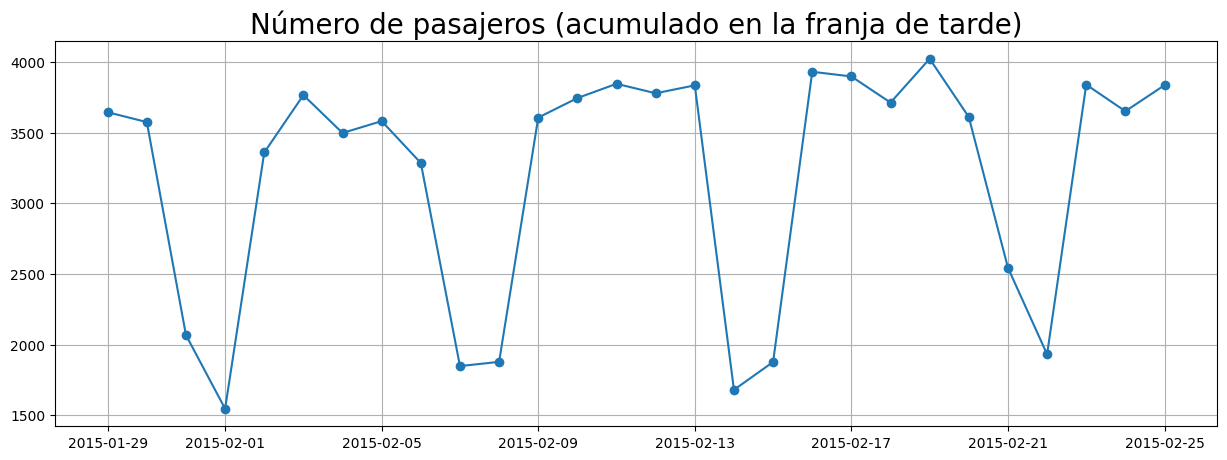

In [19]:
plt.figure(figsize=(15,5))
plt.plot(fechas[28:2*28], target[28:2*28], "o-")
plt.title("Número de pasajeros (acumulado en la franja de tarde)", fontsize=20)
plt.grid();

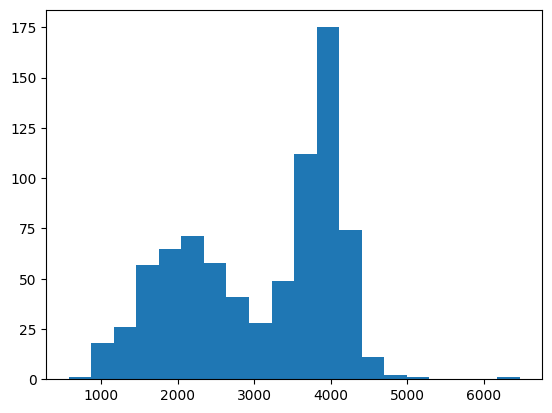

In [20]:
plt.hist(target, bins=20);

## <font color="#CA3532"> **4. Transformación de la variable a predecir**

In [21]:
# Transformación de escala (ajustar el factor en función del problema)
def transform(x):
    return x/5000
def inverse_transform(x_escalado):
    return x_escalado*5000

In [22]:
transform(np.array([1,2,3]))

array([0.0002, 0.0004, 0.0006])

In [23]:
inverse_transform(transform(np.array([1,2,3])))

array([1., 2., 3.])

## <font color="#CA3532"> **5. Enventanado de datos**

In [24]:
if COLAB:
    download_file_from_google_drive(file_id='1LYuVxpFdsoxgl89tku6BtEH3HuYcGd2g',
                                    dest_file='./my_utils_series_temporales.py.zip', unzip=True)

from my_utils_series_temporales import int2dummy, enventanar, info_enventanado, NAN

--2026-05-28 10:12:08--  https://drive.usercontent.google.com/download?id=1LYuVxpFdsoxgl89tku6BtEH3HuYcGd2g&export=download&confirm=t&uuid=9699f0e2-e760-49fc-b12e-49f140095280
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.253.117.132, 2607:f8b0:400e:c0a::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.253.117.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2010 (2.0K) [application/octet-stream]
Saving to: ‘./my_utils_series_temporales.py.zip’

./my_utils_series_t 100%[===================>]   1.96K  --.-KB/s    in 0s      

2026-05-28 10:12:09 (13.6 MB/s) - ‘./my_utils_series_temporales.py.zip’ saved [2010/2010]



In [25]:
target_transf = transform(target)
target_transf[:5]

array([0.225 , 0.7184, 0.6002, 0.452 , 0.5534])

In [26]:
# según mi librería:
series = [target_transf] # series a enventanar
se_saben_antes = [False] # adelanto o no las series
nombres_series = ["target_transf"]

print(np.shape(series))
print(np.shape(se_saben_antes))

(1, 790)
(1,)


In [27]:
lookback = 14 # tamaño ventana: lookback es otro sinónimo de W_in

# target=0 en siguiente línea quiere decir cuál es el índice del target en objeto "series":
X, y = enventanar(series, target=0, se_saben_antes=se_saben_antes,
                  W_in=lookback)

print(X.shape, np.shape(y))

(790, 14, 1) (790,)


In [28]:
X[0]

array([[nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan]])

In [29]:
y[0]

np.float64(0.225)

In [30]:
X[1]

array([[  nan],
       [  nan],
       [  nan],
       [  nan],
       [  nan],
       [  nan],
       [  nan],
       [  nan],
       [  nan],
       [  nan],
       [  nan],
       [  nan],
       [  nan],
       [0.225]])

In [31]:
y[1]

np.float64(0.7184)

In [32]:
X[3]

array([[   nan],
       [   nan],
       [   nan],
       [   nan],
       [   nan],
       [   nan],
       [   nan],
       [   nan],
       [   nan],
       [   nan],
       [   nan],
       [0.225 ],
       [0.7184],
       [0.6002]])

In [33]:
y[3]

np.float64(0.452)

In [34]:
series[0][:10]

array([0.225 , 0.7184, 0.6002, 0.452 , 0.5534, 0.2684, 0.7734, 0.7808,
       0.7356, 0.5262])

In [35]:
X[5]

array([[   nan],
       [   nan],
       [   nan],
       [   nan],
       [   nan],
       [   nan],
       [   nan],
       [   nan],
       [   nan],
       [0.225 ],
       [0.7184],
       [0.6002],
       [0.452 ],
       [0.5534]])

In [36]:
y[5]

np.float64(0.2684)

In [37]:
fechas_aux = [str(x).split("T")[0] for x in fechas]

info_enventanado(X[:10],y[:10],
                 nombres_series=nombres_series,
                 nombre_target="target",
                 tiempos=fechas_aux)

print(X.shape)
print(np.shape(target))

10 ventanas creadas

X.shape=(10, 14, 1)  Y.shape=(10,) 

 Ventana 0: 


X[0].shape=(14, 1) 
 
 
   
 ?0 
 ?1 
 ?2 
 ?3 
 ?4 
 ?5 
 ?6 
 ?7 
 ?8 
 ?9 
 ?10 
 ?11 
 ?12 
 ?13 
 
 
 
 
 target_transf 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 
 
 
__
 
 Y[0]=0.225 
 
 
   
 2015-01-01 
 
 
 
 
 target 
 0.225000

 Ventana 1: 


X[1].shape=(14, 1) 
 
 
   
 ?0 
 ?1 
 ?2 
 ?3 
 ?4 
 ?5 
 ?6 
 ?7 
 ?8 
 ?9 
 ?10 
 ?11 
 ?12 
 2015-01-01 
 
 
 
 
 target_transf 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 0.225000 
 
 
 
__
 
 Y[1]=0.7184 
 
 
   
 2015-01-02 
 
 
 
 
 target 
 0.718400

 Ventana 2: 


...

 Ventana 8: 


X[8].shape=(14, 1) 
 
 
   
 ?0 
 ?1 
 ?2 
 ?3 
 ?4 
 ?5 
 2015-01-01 
 2015-01-02 
 2015-01-03 
 2015-01-04 
 2015-01-05 
 2015-01-06 
 2015-01-07 
 2015-01-08 
 
 
 
 
 target_transf 
 nan 
 nan 
 nan 
 nan 
 nan 
 nan 
 0.225000 
 0.718400 
 0.600200 
 0.452000 
 0.553400 
 0.268400 
 0.773400 
 0.780800 
 
 
 
__
 
 Y[8]=0.7356 
 
 
   
 2015-01-09 
 
 
 
 
 target 
 0.735600

 Ventana 9: 


X[9].shape=(14, 1) 
 
 
   
 ?0 
 ?1 
 ?2 
 ?3 
 ?4 
 2015-01-01 
 2015-01-02 
 2015-01-03 
 2015-01-04 
 2015-01-05 
 2015-01-06 
 2015-01-07 
 2015-01-08 
 2015-01-09 
 
 
 
 
 target_transf 
 nan 
 nan 
 nan 
 nan 
 nan 
 0.225000 
 0.718400 
 0.600200 
 0.452000 
 0.553400 
 0.268400 
 0.773400 
 0.780800 
 0.735600 
 
 
 
__
 
 Y[9]=0.5262 
 
 
   
 2015-01-10 
 
 
 
 
 target 
 0.526200

(790, 14, 1)
(790,)


## <font color="#CA3532"> **6. Separación training-test**

In [38]:
train_perc = 0.8
punto_corte = int(len(target)*train_perc)
punto_corte

632

In [39]:
X_train = X[lookback:punto_corte]
y_train = y[lookback:punto_corte]
target_train = target[lookback:punto_corte]
fechas_train = fechas[lookback:punto_corte]

In [40]:
X_test = X[punto_corte:]
y_test = y[punto_corte:]
target_test = target[punto_corte:]
fechas_test = fechas[punto_corte:]

In [41]:
X_train.shape, y_train.shape, target_train.shape, fechas_train.shape

((618, 14, 1), (618,), (618,), (618,))

In [42]:
X_test.shape, y_test.shape, target_test.shape, fechas_test.shape

((158, 14, 1), (158,), (158,), (158,))

## <font color="#CA3532"> **7. Construcción del modelo con Keras**

In [43]:
model = Sequential()
model.add(GRU(2 , input_shape=(lookback, 1)))
model.add(Dense(1))
model.compile(loss="mean_squared_error", optimizer="rmsprop")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [44]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 2)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)


Epoch 1: val_loss improved from None to 0.10912, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.10912 to 0.08617, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.08617 to 0.06833, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.06833 to 0.05393, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.05393 to 0.04437, saving model to model_current_best.h5


...


Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02826

Epoch 1: val_loss did not improve from 0.02826

Epoch 1: val_loss did not improve from 0.02826

Epoch 1: val_loss improved from 0.02826 to 0.02801, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02801

Epoch 1: val_loss improved from 0.02801 to 0.02791, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02791

Epoch 1: val_loss improved from 0.02791 to 0.02787, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02787 to 0.02766, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02766


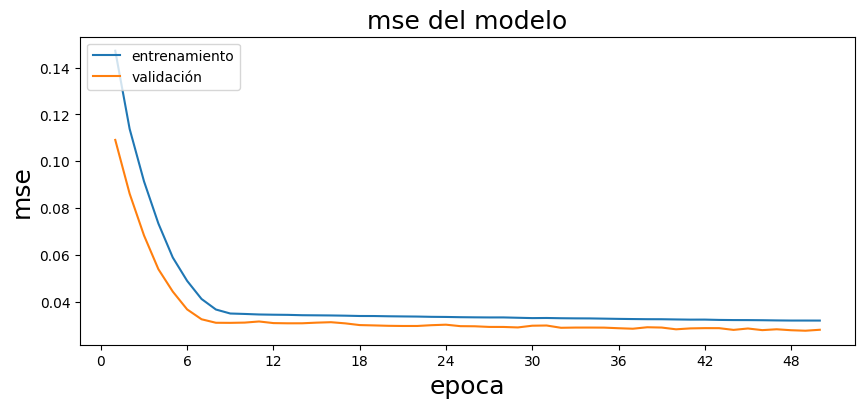


Epoch 1: val_loss improved from 0.02766 to 0.02763, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02763 to 0.02747, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02747

Epoch 1: val_loss did not improve from 0.02747

Epoch 1: val_loss did not improve from 0.02747

Epoch 1: val_loss improved from 0.02747 to 0.02732, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02732

Epoch 1: val_loss did not improve from 0.02732

Epoch 1: val_loss did not improve from 0.02732

Epoch 1: val_loss did not improve from 0.02732

Epoch 1: val_loss improved from 0.02732 to 0.02729, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02729

Epoch 1: val_loss improved from 0.02729 to 0.02704, saving model to model_current_best.h5


...


Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02596

Epoch 1: val_loss improved from 0.02596 to 0.02591, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02591

Epoch 1: val_loss improved from 0.02591 to 0.02590, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02590 to 0.02585, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02585

Epoch 1: val_loss did not improve from 0.02585

Epoch 1: val_loss did not improve from 0.02585

Epoch 1: val_loss did not improve from 0.02585

Epoch 1: val_loss did not improve from 0.02585

Epoch 1: val_loss improved from 0.02585 to 0.02569, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02569

Epoch 1: val_loss did not improve from 0.02569


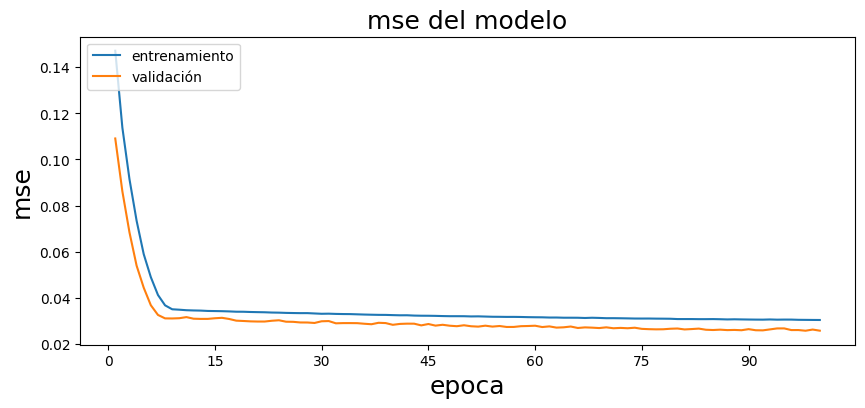


Epoch 1: val_loss did not improve from 0.02569

Epoch 1: val_loss improved from 0.02569 to 0.02558, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02558

Epoch 1: val_loss did not improve from 0.02558

Epoch 1: val_loss did not improve from 0.02558

Epoch 1: val_loss improved from 0.02558 to 0.02547, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02547

Epoch 1: val_loss did not improve from 0.02547

Epoch 1: val_loss improved from 0.02547 to 0.02546, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02546

Epoch 1: val_loss did not improve from 0.02546

Epoch 1: val_loss did not improve from 0.02546

Epoch 1: val_loss did not improve from 0.02546

Epoch 1: val_loss did not improve from 0.02546

Epoch 1: val_loss did not improve from 0.02546

Epoch 1: val_loss did not improve from 0.02546

Epoch 1: val_loss did not improve from 0.02546

Epoch 1: val_loss did not improve from 0.02546

Epoch 1: val_loss improved from 0.02546 to 0.02525, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02525

Epoch 1: val_loss did not improve from 0.02525

Epoch 1: val_loss improved from 0.02525 to 0.02517, saving model to model_current_best.h5


...


Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02472 to 0.02469, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02469

Epoch 1: val_loss improved from 0.02469 to 0.02464, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02464 to 0.02460, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02460

Epoch 1: val_loss did not improve from 0.02460

Epoch 1: val_loss did not improve from 0.02460

Epoch 1: val_loss did not improve from 0.02460

Epoch 1: val_loss did not improve from 0.02460

Epoch 1: val_loss did not improve from 0.02460

Epoch 1: val_loss improved from 0.02460 to 0.02447, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02447


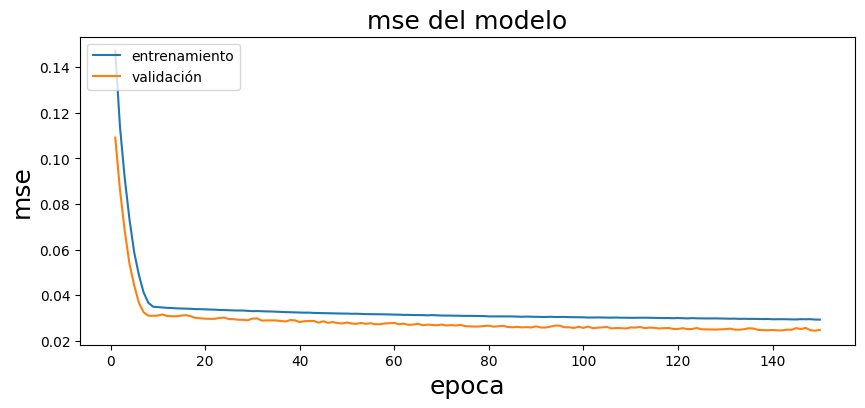


Epoch 1: val_loss did not improve from 0.02447

Epoch 1: val_loss did not improve from 0.02447

Epoch 1: val_loss did not improve from 0.02447

Epoch 1: val_loss improved from 0.02447 to 0.02443, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02443 to 0.02431, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02431

Epoch 1: val_loss improved from 0.02431 to 0.02425, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02425

Epoch 1: val_loss did not improve from 0.02425

Epoch 1: val_loss did not improve from 0.02425

Epoch 1: val_loss improved from 0.02425 to 0.02419, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02419 to 0.02414, saving model to model_current_best.h5


...


Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02345

Epoch 1: val_loss improved from 0.02345 to 0.02342, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02342 to 0.02339, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02339

Epoch 1: val_loss did not improve from 0.02339

Epoch 1: val_loss did not improve from 0.02339

Epoch 1: val_loss improved from 0.02339 to 0.02329, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02329

Epoch 1: val_loss improved from 0.02329 to 0.02323, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02323


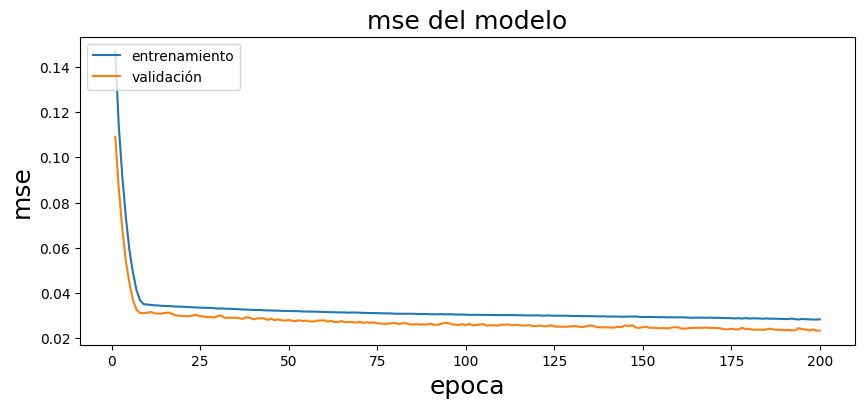


Epoch 1: val_loss did not improve from 0.02323

Epoch 1: val_loss did not improve from 0.02323

Epoch 1: val_loss improved from 0.02323 to 0.02319, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02319

Epoch 1: val_loss improved from 0.02319 to 0.02315, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02315

Epoch 1: val_loss did not improve from 0.02315

Epoch 1: val_loss did not improve from 0.02315

Epoch 1: val_loss improved from 0.02315 to 0.02299, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02299

Epoch 1: val_loss did not improve from 0.02299

Epoch 1: val_loss improved from 0.02299 to 0.02293, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02293

Epoch 1: val_loss improved from 0.02293 to 0.02288, saving model to model_current_best.h5


...


Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02233 to 0.02233, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02233

Epoch 1: val_loss did not improve from 0.02233

Epoch 1: val_loss did not improve from 0.02233

Epoch 1: val_loss did not improve from 0.02233

Epoch 1: val_loss did not improve from 0.02233

Epoch 1: val_loss improved from 0.02233 to 0.02219, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02219

Epoch 1: val_loss improved from 0.02219 to 0.02216, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02216

Epoch 1: val_loss did not improve from 0.02216

Epoch 1: val_loss improved from 0.02216 to 0.02213, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5


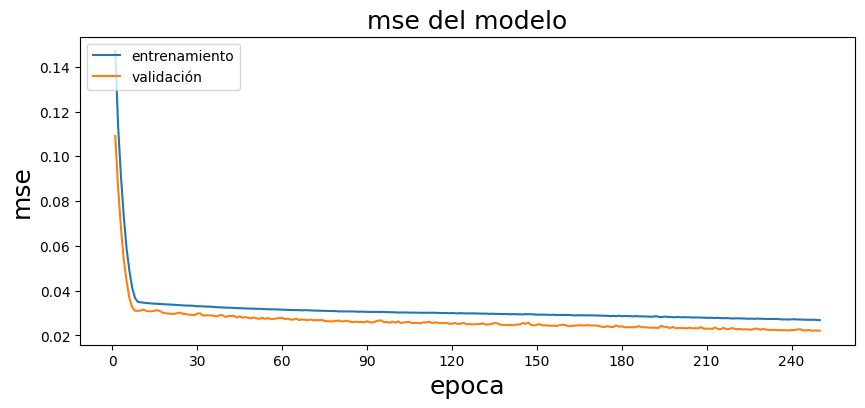


Epoch 1: val_loss did not improve from 0.02213

Epoch 1: val_loss improved from 0.02213 to 0.02206, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02206

Epoch 1: val_loss improved from 0.02206 to 0.02204, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02204 to 0.02200, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02200 to 0.02196, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02196 to 0.02193, saving model to model_current_best.h5


...


Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02147

Epoch 1: val_loss did not improve from 0.02147

Epoch 1: val_loss did not improve from 0.02147

Epoch 1: val_loss improved from 0.02147 to 0.02140, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02140

Epoch 1: val_loss improved from 0.02140 to 0.02134, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02134

Epoch 1: val_loss did not improve from 0.02134

Epoch 1: val_loss did not improve from 0.02134

Epoch 1: val_loss improved from 0.02134 to 0.02132, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02132

Epoch 1: val_loss did not improve from 0.02132

Epoch 1: val_loss improved from 0.02132 to 0.02125, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02125

Epoch 1: val_loss did not improve from 0.02125

Epoch 1: val_loss did not improve from 0.02125

Epoch 1: val_loss did not improve from 0.02125


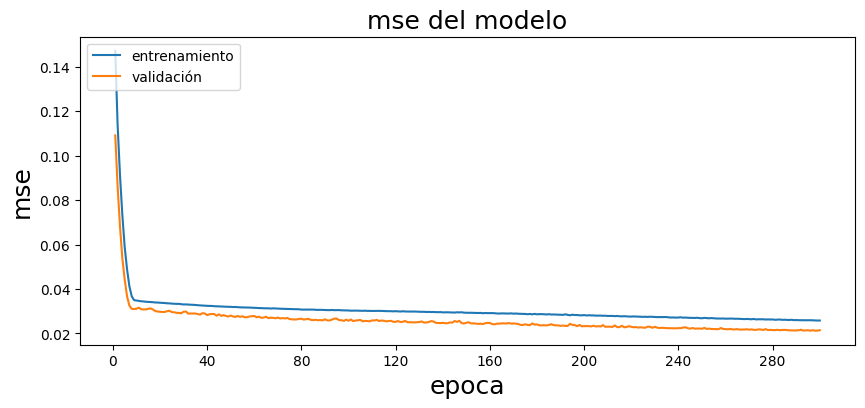


Epoch 1: val_loss did not improve from 0.02125

Epoch 1: val_loss did not improve from 0.02125

Epoch 1: val_loss improved from 0.02125 to 0.02121, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02121 to 0.02115, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02115 to 0.02107, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02107

Epoch 1: val_loss did not improve from 0.02107

Epoch 1: val_loss did not improve from 0.02107

Epoch 1: val_loss did not improve from 0.02107

Epoch 1: val_loss improved from 0.02107 to 0.02103, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02103

Epoch 1: val_loss improved from 0.02103 to 0.02094, saving model to model_current_best.h5


...


Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02053 to 0.02044, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02044

Epoch 1: val_loss did not improve from 0.02044

Epoch 1: val_loss improved from 0.02044 to 0.02042, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.02042 to 0.02035, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02035

Epoch 1: val_loss did not improve from 0.02035

Epoch 1: val_loss did not improve from 0.02035

Epoch 1: val_loss improved from 0.02035 to 0.02027, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5


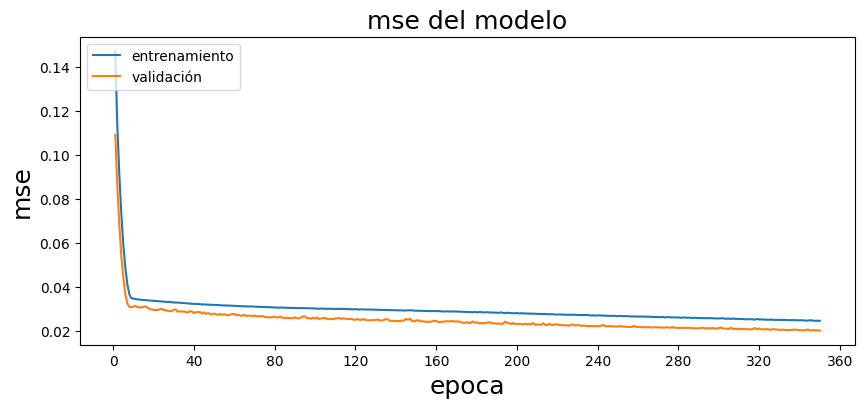


Epoch 1: val_loss did not improve from 0.02027

Epoch 1: val_loss improved from 0.02027 to 0.02027, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02027

Epoch 1: val_loss improved from 0.02027 to 0.02023, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02023

Epoch 1: val_loss did not improve from 0.02023

Epoch 1: val_loss improved from 0.02023 to 0.02016, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02016

Epoch 1: val_loss did not improve from 0.02016

Epoch 1: val_loss did not improve from 0.02016

Epoch 1: val_loss did not improve from 0.02016

Epoch 1: val_loss did not improve from 0.02016

Epoch 1: val_loss improved from 0.02016 to 0.02015, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.02015

Epoch 1: val_loss improved from 0.02015 to 0.02008, saving model to model_current_best.h5


...


Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01974

Epoch 1: val_loss did not improve from 0.01974

Epoch 1: val_loss did not improve from 0.01974

Epoch 1: val_loss improved from 0.01974 to 0.01974, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01974

Epoch 1: val_loss improved from 0.01974 to 0.01969, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.01969 to 0.01964, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01964

Epoch 1: val_loss did not improve from 0.01964

Epoch 1: val_loss did not improve from 0.01964

Epoch 1: val_loss did not improve from 0.01964

Epoch 1: val_loss did not improve from 0.01964

Epoch 1: val_loss did not improve from 0.01964

Epoch 1: val_loss did not improve from 0.01964

Epoch 1: val_loss improved from 0.01964 to 0.01959, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01959


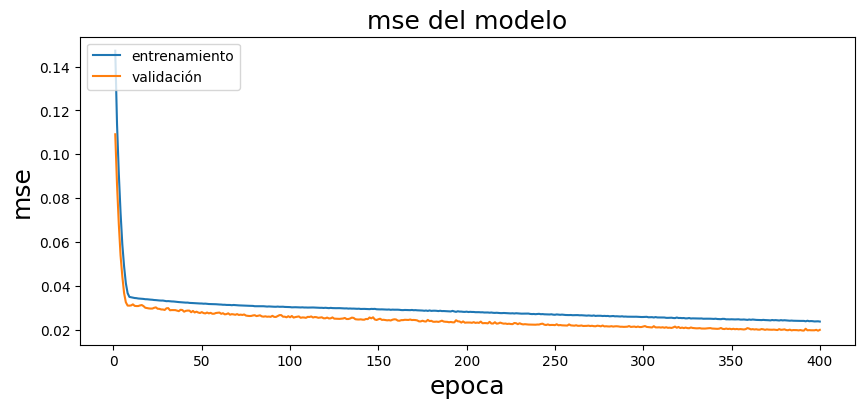


Epoch 1: val_loss improved from 0.01959 to 0.01957, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.01957 to 0.01957, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01957

Epoch 1: val_loss improved from 0.01957 to 0.01950, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.01950 to 0.01934, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01934

Epoch 1: val_loss did not improve from 0.01934

Epoch 1: val_loss did not improve from 0.01934

Epoch 1: val_loss did not improve from 0.01934

Epoch 1: val_loss did not improve from 0.01934

Epoch 1: val_loss did not improve from 0.01934

Epoch 1: val_loss did not improve from 0.01934

Epoch 1: val_loss did not improve from 0.01934

Epoch 1: val_loss improved from 0.01934 to 0.01926, saving model to model_current_best.h5


...


Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01868

Epoch 1: val_loss did not improve from 0.01868

Epoch 1: val_loss did not improve from 0.01868

Epoch 1: val_loss did not improve from 0.01868

Epoch 1: val_loss improved from 0.01868 to 0.01860, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01860

Epoch 1: val_loss improved from 0.01860 to 0.01856, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01856

Epoch 1: val_loss did not improve from 0.01856

Epoch 1: val_loss improved from 0.01856 to 0.01854, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01854

Epoch 1: val_loss improved from 0.01854 to 0.01838, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01838


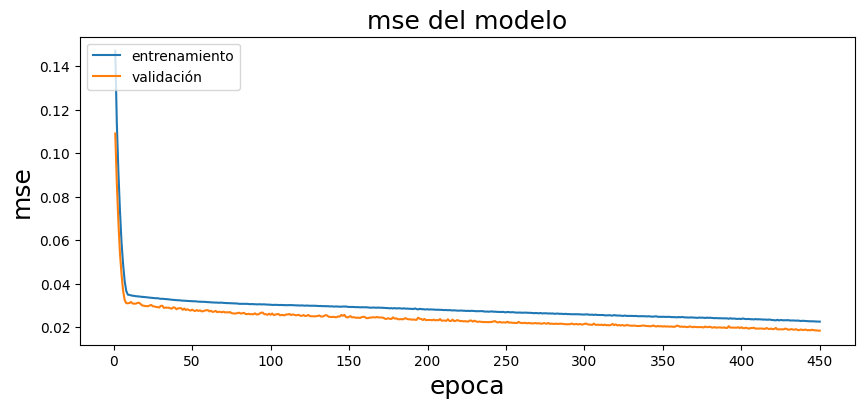


Epoch 1: val_loss improved from 0.01838 to 0.01835, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01835

Epoch 1: val_loss did not improve from 0.01835

Epoch 1: val_loss did not improve from 0.01835

Epoch 1: val_loss improved from 0.01835 to 0.01821, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.01821 to 0.01820, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.01820 to 0.01818, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.01818 to 0.01816, saving model to model_current_best.h5


...


Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss improved from 0.01646 to 0.01644, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01644

Epoch 1: val_loss improved from 0.01644 to 0.01643, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01643

Epoch 1: val_loss improved from 0.01643 to 0.01605, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_loss did not improve from 0.01605

Epoch 1: val_loss did not improve from 0.01605

Epoch 1: val_loss improved from 0.01605 to 0.01594, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5


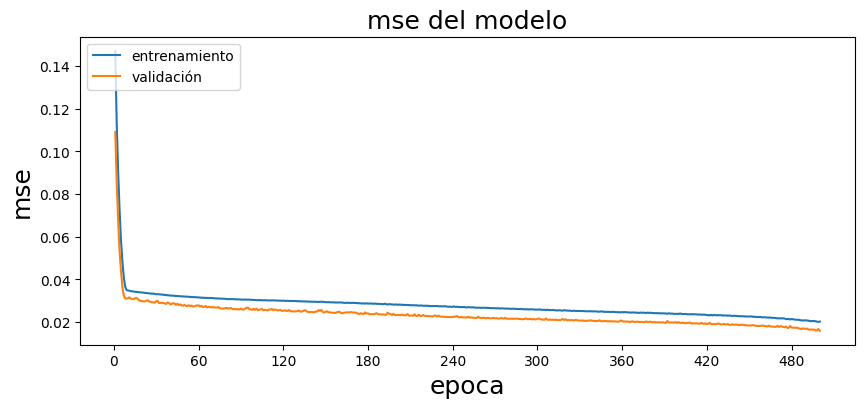

In [45]:
epochs = 500
Nval = 200
#batch_size = len(X_train[:-Nval]) # 128
batch_size = 32

control_sobreajuste_val = True

# Ahora train lo divido en tr (con el que realmente entreno)
# & val (con el que valido)
X_tr  = X_train[:-Nval] # quitando los 200 últimos valores
y_tr  = y_train[:-Nval]
X_val = X_train[-Nval:] # los 200 últimos valores
y_val = y_train[-Nval:]

if not control_sobreajuste_val:
    history = model.fit(X_train, y_train, epochs=epochs,
                        batch_size=batch_size, verbose=2)
else:
    acum_tr_mse = []
    acum_val_mse = []
    modelpath="model_current_best.h5"
    checkpoint = ModelCheckpoint(modelpath, monitor='val_loss', verbose=2, # val_mean_squared_error
                                 save_best_only=True,
                                 mode='min') # graba sólo los que mejoran en validación

    callbacks_list = [checkpoint]

    for e in range(epochs):
        history = model.fit(X_tr, y_tr,
                            batch_size=batch_size,
                            epochs=1,
                            callbacks=callbacks_list,
                            verbose=0,
                            validation_data=(X_val, y_val))

        acum_tr_mse  += history.history['loss'] # mean_squared_error
        acum_val_mse += history.history['val_loss'] # val_mean_squared_error

        if (e+1)%50 == 0:
            grafica_entrenamiento(acum_tr_mse, acum_val_mse)

model = load_model(modelpath) # recupero el mejor modelo en validación

## <font color="#CA3532"> **8. Chequeo del modelo (predicción a un día)**

In [46]:
y_train_prediction = model.predict(X_train, verbose=0).flatten()
target_train_pred = inverse_transform(y_train_prediction)

y_test_prediction  = model.predict(X_test, verbose=0).flatten()
target_test_pred = inverse_transform(y_test_prediction)

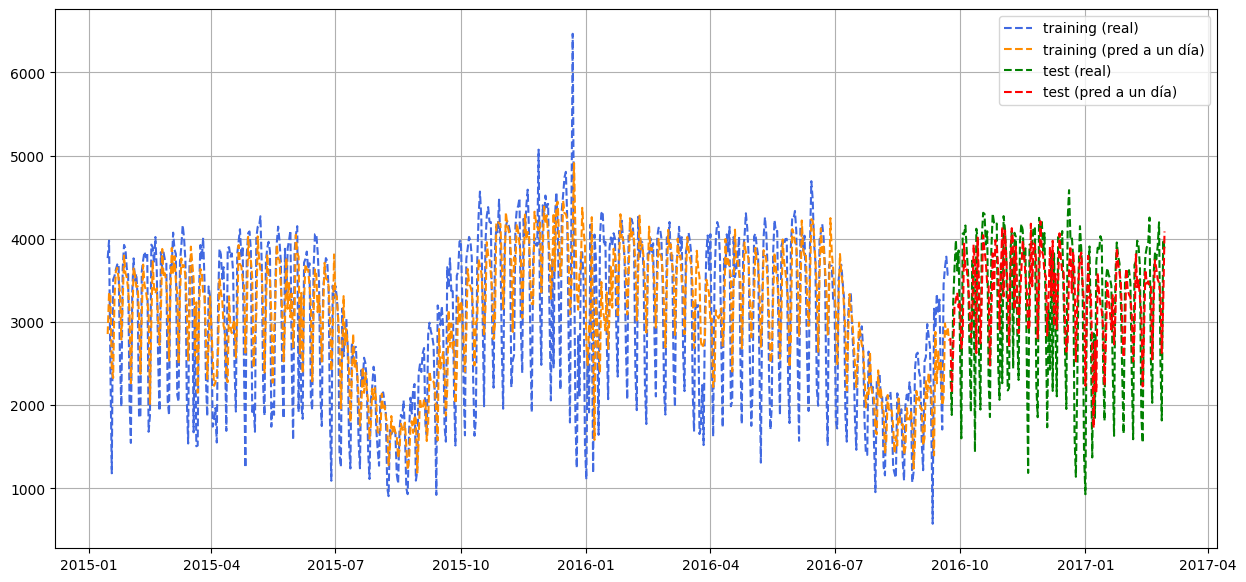

In [47]:
plt.figure(figsize=(15,7))
plt.plot(fechas_train, target_train, "--", c="royalblue", label="training (real)")
plt.plot(fechas_train, target_train_pred, "--", c="darkorange", label="training (pred a un día)")
plt.plot(fechas_test, target_test, "--", c="green", label="test (real)")
plt.plot(fechas_test, target_test_pred, "--", c="red", label="test (pred a un día)")
plt.legend()
plt.grid();

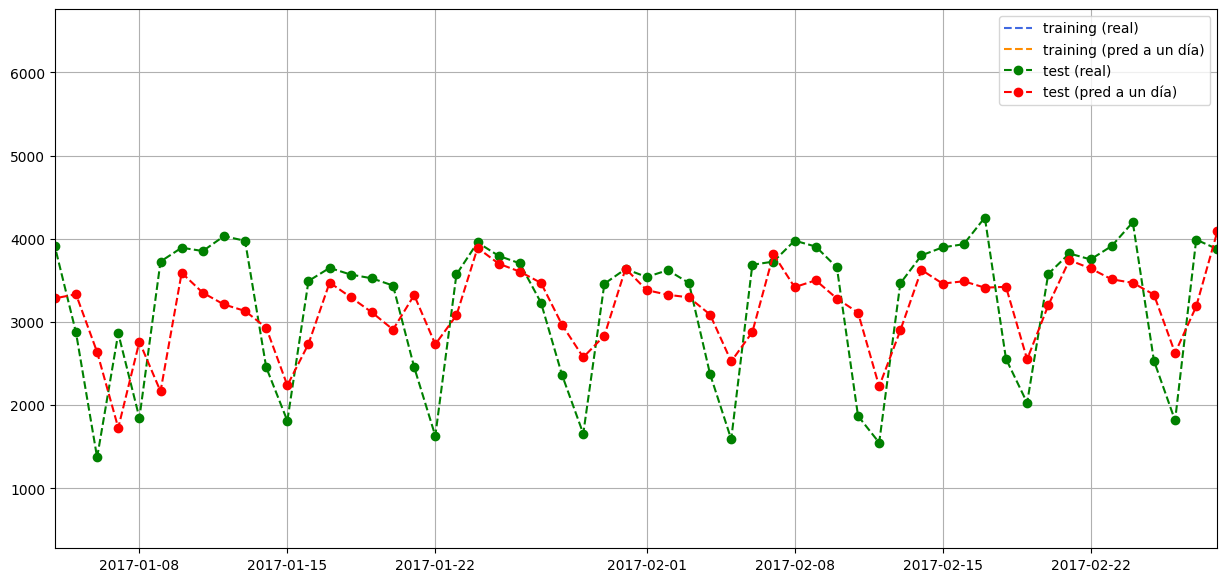

In [48]:
plt.figure(figsize=(15,7))
plt.plot(fechas_train, target_train, "--", c="royalblue", label="training (real)")
plt.plot(fechas_train, target_train_pred, "--", c="darkorange", label="training (pred a un día)")
plt.plot(fechas_test, target_test, "--o", c="green", label="test (real)")
plt.plot(fechas_test, target_test_pred, "--o", c="red", label="test (pred a un día)")
plt.legend()
plt.xlim([fechas_test[-28*2], fechas_test[-1]])
plt.grid();

In [49]:
np.sqrt(((target_test_pred - target_test)**2).mean())

np.float64(762.5640692231449)

In [50]:
np.sqrt(((target_test[:-1] - target_test[1:])**2).mean())

np.float64(1093.8023843688381)

In [51]:
R2_score(target_test, target_test_pred)

0.29577600955963135

In [52]:
R2_score(target_test[1:], target_test[:-1])

-0.44768351889101354

## <font color="#CA3532"> **9. Predicciones a varios días en test mediante un modelo auto-regresivo**

In [53]:
#1000, 1200, 1300 -> 1400
#1200, 1300, 1400 -> 1500
#1300, 1400, 1500

In [54]:
def step_autoregresivo(model, ventana, X, i):
    # ventana: va a tener dimensiones (1, lookback, n_variables)
    # El target está en (0,:,0)
    # La posición (0,0,0) es el target en el día más antiguo de la ventana
    # La posición (0,0,-1) es el target en el día más reciente de la ventana
    # Las variables calendario están en (0,:,1:)
    # Las variables calendario para el último día de la ventana están en (0,-1,1:)

    z = model.predict(ventana, verbose=0)[0,0] # predicción nueva
    target_pred = inverse_transform(z)
    ventana_nueva = None
    if i < (len(X)-1):
        ventana_nueva = np.zeros(ventana.shape)
        # muevo un día hacia atrás todas las variables de la ventana:
        ventana_nueva[0,:-1,:] = ventana[0,1:,:].copy()

        # introduzco las variables calendario para el último día de la ventana:
        ventana_nueva[0,-1,1:] = X[i+1,-1,1:]

        # meto la predicción como última obervación del target:
        ventana_nueva[0,-1,0] = z


    return target_pred, ventana_nueva

In [55]:
def autoregresivo(model, X):
    ventana = np.array([X[0]]).copy()
    salidas = []
    for i in range(len(X)):
        target_pred, ventana_nueva = step_autoregresivo(model, ventana, X, i)
        salidas.append(target_pred)
        ventana = ventana_nueva

    return salidas

In [56]:
sal = autoregresivo(model, X_test)

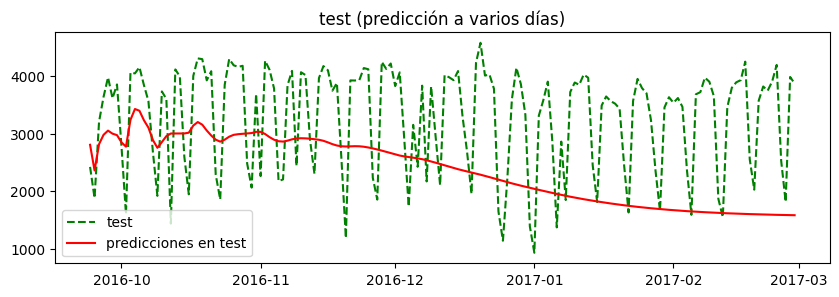

In [57]:
fig = plt.figure(figsize=(10,3))
ax = fig.add_subplot(1,1,1)
ax.plot(fechas_test, target_test, '--g', label='test')
plt.plot(fechas_test, sal, 'r', label='predicciones en test')
plt.title('test (predicción a varios días)')
plt.legend();